<a href="https://colab.research.google.com/github/Eikthyrnir/CatVTON_3DGS/blob/main/CatVTON_sandbox_save_env.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CatVTON basic front inference example

## Connect to Google Drive
It is convenient to load data from external source than manually drag it into colab env

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Persistent Environment (Backup & Restore)
This cell configures a custom installation directory and restores it from Google Drive if a backup exists. This allows us to skip downloading and compiling large packages (like xformers and PyTorch) across sessions.

In [11]:
import os
import sys
import site

ENV_DIR = '/content/my_env'
ENV_TAR = '/content/drive/MyDrive/colab_env.tar.gz'

os.makedirs(ENV_DIR, exist_ok=True)

# 1. Tell Python to look for packages in our custom directory
# site.addsitedir processes special .pth files used by complex packages
site.addsitedir(ENV_DIR)
# sys.path.insert ensures our directory takes highest priority
sys.path.insert(0, ENV_DIR)

# 2. Set PYTHONPATH so subprocesses (like !python scripts) can find the packages
os.environ['PYTHONPATH'] = f"{ENV_DIR}:{os.environ.get('PYTHONPATH', '')}"

# 3. Force pip to install all future packages into this custom directory automatically
os.environ['PIP_TARGET'] = ENV_DIR

# 4. Restore the environment if a backup exists on Drive
if os.path.exists(ENV_TAR):
    print(f"Found existing environment backup at {ENV_TAR}.")
    print("Extracting to local disk... (this takes ~30-60 seconds)")
    !tar -xzf {ENV_TAR} -C /
    print("\n✅ Environment restored successfully! You can SKIP the 'pip install' cells below.")
else:
    print("No backup found on Drive. Proceed with the normal installation cells below.")
    print("Once all installations are done, run 'backup_env()' to save the environment for next time.")

def backup_env():
    """Run this function AFTER all installations are complete to save the environment."""
    print(f"Compressing {ENV_DIR} into {ENV_TAR}...")
    !tar -czf {ENV_TAR} -C / content/my_env
    print("\n✅ Environment backed up successfully to Google Drive!")


No backup found on Drive. Proceed with the normal installation cells below.
Once all installations are done, run 'backup_env()' to save the environment for next time.


In [ ]:
# Alternative to mounting google drive: upload only few necessary files from local computer

# from google.colab import files

# uploaded = files.upload()

# for fn in uploaded.keys():
#   print('User uploaded file "{name}" with length {length} bytes'.format(
#       name=fn, length=len(uploaded[fn])))

### Setup Pip Cache to google drive
By saving the pip cache to Google Drive, we can avoid re-downloading and re-building packages across Colab sessions.

In [ ]:
import os

# Create a directory on Drive to store the pip cache
CACHE_DIR = '/content/drive/MyDrive/colab_pip_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

# Set the environment variable so pip uses this directory automatically
os.environ['PIP_CACHE_DIR'] = CACHE_DIR

## CatVTON installation

In [ ]:
# Клонируем репозиторий CatVTON
!git clone https://github.com/Zheng-Chong/CatVTON.git
%cd CatVTON

In [ ]:
# Устанавливаем зависимости из requirements.txt
!pip install -r requirements.txt

In [ ]:
# Обновляем accelerate до последней версии (1.13.0) и ставим стабильный diffusers
!pip install -U accelerate==1.13.0 diffusers==0.30.3 peft huggingface_hub

In [10]:
# Install fvcore to fix the ModuleNotFoundError
!pip install fvcore

In [ ]:
# Clean up existing conflicting installations first
!pip uninstall -y torch torchvision torchaudio xformers

# Upgrade setuptools to provide the distutils shim required by Python 3.12
!pip install setuptools --upgrade

# Устанавливаем PyTorch 2.4.1 (CUDA 12.4) и совместимую с Python 3.12 версию xformers
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu124
!pip install xformers==0.0.28.post1

In [ ]:
!nvcc --version

import torch
print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)

## Load sample garment and person

In [ ]:
import urllib.request

# test human-model image (front view)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Zheng-Chong/CatVTON/main/resource/demo/example/person/men/model_5.png",
    "person.png"
)

# test garment image
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Zheng-Chong/CatVTON/main/resource/demo/example/condition/upper/24083449_54173465_2048.jpg",
    "garment.jpg"
)

## CatVTON imports

In [6]:
%cd CatVTON

[Errno 2] No such file or directory: 'CatVTON'
/content/CatVTON


In [13]:
# Upgrade transformers and huggingface-hub to satisfy diffusers requirements
!pip install -U transformers huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 150.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 139.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
# Install PyAV (av) to resolve the ModuleNotFoundError
!pip install av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 78.3 MB/s eta 0:00:00


In [15]:
# Upgrade xformers to a version >= 0.0.28.post2 to fix Python 3.12 type annotation errors.
# We must also upgrade torchvision to match the torch 2.5.0 requirement to prevent torchvision::nms CUDA errors.
!pip install torch==2.5.0 torchvision==0.20.0 torchaudio==2.5.0 xformers==0.0.28.post2 --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 126.1 MB/s eta 0:00:00
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.19.1+cu124
    Uninstalling torchvision-0.19.1+cu124:
      Successfully uninstalled torchvision-0.19.1+cu124
  Attempting uninstall: torchaudio
    Found existing installation: torchaudio 2.4.1+cu124
    Uninstalling torchaudio-2.4.1+cu124:
      Successfully uninstalled torchaudio-2.4.1+cu124


In [1]:
%cd CatVTON

/content/CatVTON


In [2]:
import torch
from PIL import Image
from huggingface_hub import snapshot_download

import os
import gc

# imports from CatVTON
from model.cloth_masker import AutoMasker
from model.pipeline import CatVTONPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

## Initializing CatVTON models

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
from diffusers import AutoencoderKL
import torch

weight_dtype = torch.float16

base_model_path = "runwayml/stable-diffusion-inpainting"
catvton_model_path = "zhengchong/CatVTON"

pipeline = CatVTONPipeline(
    base_ckpt=base_model_path,
    attn_ckpt=catvton_model_path,
    attn_ckpt_version="mix",
    weight_dtype=weight_dtype,
    device=device,
    skip_safety_check=True
)

# Fix for the pink mask overlay and brown artifacts on T4:
# We use the official MSE-finetuned VAE which is safe in float16 and maintains high quality.
pipeline.vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=weight_dtype).to(device)

# Built-in memory optimization
try:
    pipeline.enable_xformers_memory_efficient_attention()
    print("xformers optimization enabled.")
except Exception:
    print("Using built-in SDPA optimization.")

try:
    if hasattr(pipeline, "enable_model_cpu_offload"):
        pipeline.enable_model_cpu_offload()
        print("CPU offloading enabled!")
except Exception as e:
    print(f"Failed to enable CPU offloading: {e}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Downloaded zhengchong/CatVTON to /root/.cache/huggingface/hub/models--zhengchong--CatVTON/snapshots/2969fcf85fe62f2036605716f0b56f0b81d01d79
Using built-in SDPA optimization.


In [6]:
# Скачиваем основной репозиторий с весами (или берем из кэша)
repo_path = snapshot_download(repo_id="zhengchong/CatVTON")

# Инициализация модуля для автоматического создания масок с использованием путей внутри основного репозитория
automasker = AutoMasker(
    densepose_ckpt=os.path.join(repo_path, "DensePose"),
    schp_ckpt=os.path.join(repo_path, "SCHP"),
    device=device
)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

/content/CatVTON/model/SCHP/__init__.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location='cpu')['state_dict']


## Utility functions

In [7]:
def show_try_on_res(person, mask, try_on_result):
    fig, axs = plt.subplots(1, 3, figsize=(15, 6))

    axs[0].imshow(person)
    axs[0].set_title("Front Result (Reference)")
    axs[0].axis('off')

    axs[1].imshow(mask)
    axs[1].set_title("Try-On Mask")
    axs[1].axis('off')

    axs[2].imshow(try_on_result.resize(target_size))
    axs[2].set_title("Try-On Result")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

In [8]:
def show_multiple_images(images):
    n_images = len(images)
    fig, axs = plt.subplots(1, n_images, figsize=(5 * n_images, 6))

    if n_images == 1:
        axs.imshow(images[0])
        axs.axis('off')
    else:
        for i in range(n_images):
            axs[i].imshow(images[i])
            axs[i].axis('off')

    plt.tight_layout()
    plt.show()

## Copy files from drive

In [9]:
!mkdir /content/clothes
!cp -r /content/drive/MyDrive/weavella/images/cloth_from_zoolando_website /content/clothes

mkdir: cannot create directory ‘/content/clothes’: File exists


## Example inference on front view

In [10]:
NUM_INFERENCE_STEPS_CAT_VTON = 50

In [11]:
# 1. Load images
person_path = "/content/person.png"
# garment_path = "/content/garment.jpg"
garment_folder = "/content/clothes/cloth_from_zoolando_website/jack-and-jones-jorsnake-crew-neck-t-shirt-z-nadrukiem-antique-white-ja222o5zp-a11"
# On person
garment_path = garment_folder + "/6d51a17dfd0343a5a27b5971c92bfae9.webp"
garment_path = garment_folder + "/c4894c7140ca48f6af9b8cd05c2adc25.webp"
garment_path = garment_folder + "/9cbddc78aa24472e87bdec578049891c.webp"
garment_path = garment_folder + "/833fd6835df54ece81b53c66de90dd48.webp"
# pure flat-out t-shirt image
garment_path = garment_folder + "/c238569c66eb42578c5a787c54e43731.webp"
garment_path = garment_folder + "/ceac3aa9af9b451d8aa29df6cf5db6dc.webp"

person_image = Image.open(person_path).convert("RGB")
garment_image = Image.open(garment_path).convert("RGB")

# size of the images for CatVTON
target_size = (768, 1024)
person_image = person_image.resize(target_size)
garment_image = garment_image.resize(target_size)

In [12]:
# 1. Clear memory before running
torch.cuda.empty_cache()
gc.collect()

# 2. Generate mask
print("Generating mask...")
mask_result = automasker(person_image)
mask = mask_result['mask']

# 3. Run inference

print("Running inference (try-on). This may take a couple of minutes...")

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

result_image = pipeline(
    image=person_image,
    condition_image=garment_image,
    mask=mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

Generating mask...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Running inference (try-on). This may take a couple of minutes...


100%|██████████| 50/50 [00:08<00:00,  5.92it/s]


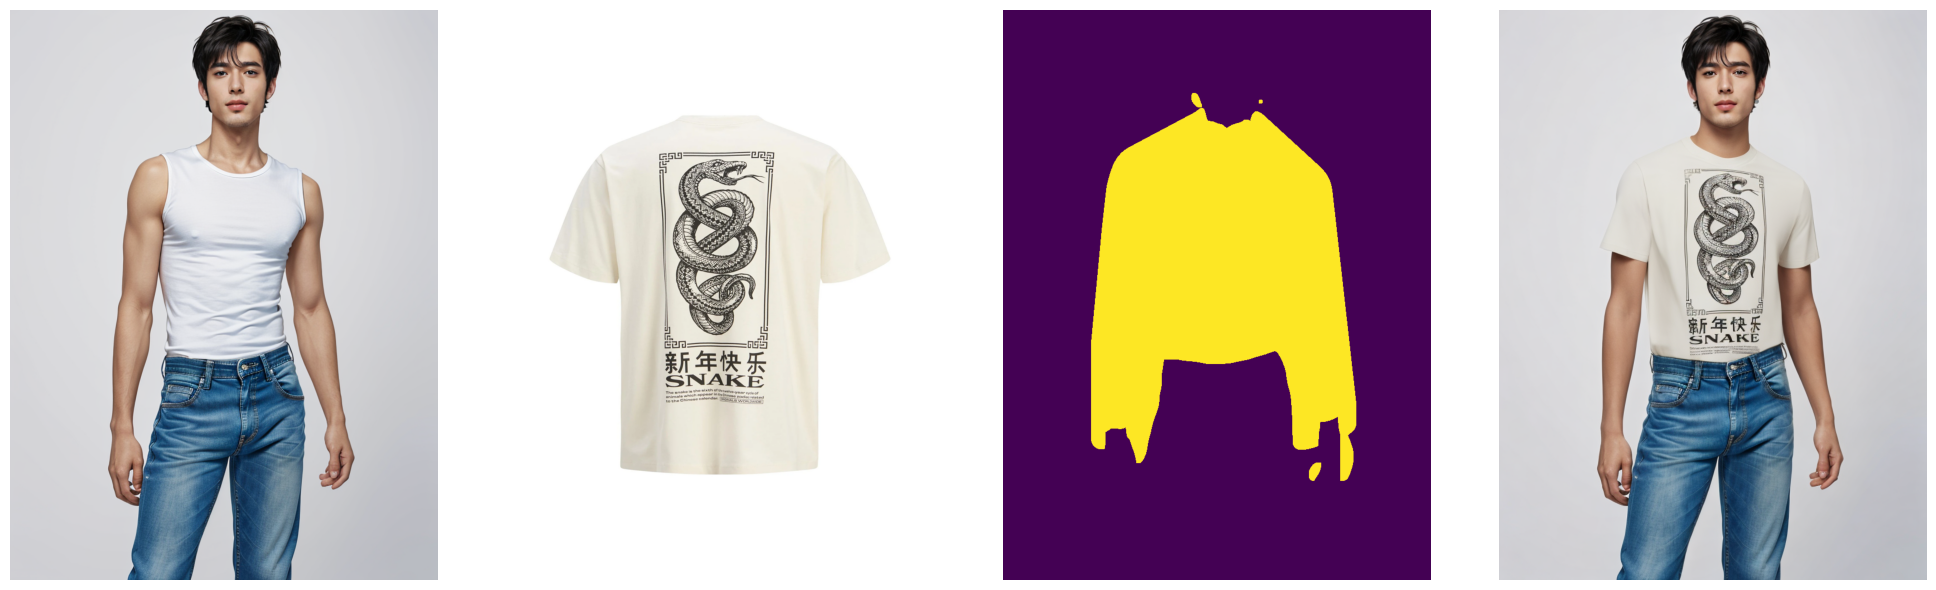

In [15]:
show_multiple_images((person_image, garment_image, mask, result_image))

# Modifying the U-Net for Reference-Driven Editing (consistent side-view try-on generation)

## Defining custon Reference Attention Processor

In [16]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from diffusers.models.attention_processor import Attention

class ReferenceAttentionProcessor:
    def __init__(self):
        self.is_reference_pass = True
        self.bank_k = []
        self.bank_v = []
        self.step_idx = 0
        self.injection_steps = range(5, 45)

    def clear_bank(self):
        self.bank_k.clear()
        self.bank_v.clear()
        self.step_idx = 0

    def reset_read_index(self):
        self.step_idx = 0

    def __call__(
        self,
        attn: Attention,
        hidden_states: torch.Tensor,
        encoder_hidden_states=None,
        attention_mask=None,
        **kwargs,
    ):
        batch_size, sequence_length, _ = hidden_states.shape

        # 1. Get Q, K, V using built-in attention layers
        query = attn.to_q(hidden_states)
        key = attn.to_k(hidden_states)
        value = attn.to_v(hidden_states)

        inner_dim = key.shape[-1]
        head_dim = inner_dim // attn.heads

        # Transform dimensions to 4D for Flash Attention: (batch, heads, seq_len, head_dim)
        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        if self.is_reference_pass:
            # ОФФЛОАД НА CPU: сохраняем K и V в оперативную память
            self.bank_k.append(key.clone().detach().cpu())
            self.bank_v.append(value.clone().detach().cpu())
        else:
            # Извлекаем K и V строго для СООТВЕТСТВУЮЩЕГО шага
            if self.step_idx in self.injection_steps and self.step_idx < len(self.bank_k):
                # ВОЗВРАТ НА GPU: переносим нужный тензор обратно в память видеокарты
                ref_k = self.bank_k[self.step_idx].to(key.device)
                ref_v = self.bank_v[self.step_idx].to(value.device)

                # Handle batch mismatch (due to Classifier-Free Guidance)
                if key.shape[0] != ref_k.shape[0]:
                    multiplier = key.shape[0] // ref_k.shape[0]
                    ref_k = ref_k.repeat(multiplier, 1, 1, 1)
                    ref_v = ref_v.repeat(multiplier, 1, 1, 1)

                # Concatenate along the spatial dimension (dim=2 in 4D tensor)
                key = torch.cat([ref_k, key], dim=2)
                value = torch.cat([ref_v, value], dim=2)

            self.step_idx += 1

        # 3. Memory-efficient Attention computation (SDPA)
        # Using 4D tensors enables memory-efficient / Flash Attention in PyTorch
        with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=False, enable_mem_efficient=True):
            try:
                hidden_states = F.scaled_dot_product_attention(
                    query, key, value, dropout_p=0.0, is_causal=False
                )
            except RuntimeError:
                # Fallback to math if necessary
                with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=True, enable_mem_efficient=True):
                    hidden_states = F.scaled_dot_product_attention(
                        query, key, value, dropout_p=0.0, is_causal=False
                    )

        # Reshape back to expected format
        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)

        # Linear projections and dropout
        hidden_states = attn.to_out[0](hidden_states)
        if len(attn.to_out) > 1:
            hidden_states = attn.to_out[1](hidden_states)

        return hidden_states

# --- Integration into CatVTON pipeline ---
# 2. Replace standard attention layers in U-Net with our custom one ONLY for up_blocks!
attn_processors = {}
for name in pipeline.unet.attn_processors.keys():
    # Инициализируем наш кастомный процессор только для attn1 в up_blocks
    if "attn1" in name and "up_blocks" in name:
        print(f"replaced attn_processors[{name}] = {pipeline.unet.attn_processors.get(name, None)} with custom attention processor")
        attn_processors[name] = ReferenceAttentionProcessor()
    else:
        # Для всех остальных слоев (включая down_blocks и mid_block) оставляем дефолтные оптимизированные процессоры
        attn_processors[name] = pipeline.unet.attn_processors[name]

pipeline.unet.set_attn_processor(attn_processors)


replaced attn_processors[up_blocks.1.attentions.0.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.1.attentions.1.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.1.attentions.2.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.2.attentions.0.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.2.attentions.1.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.2.attentions.2.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.3.attentions.0.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn

## Testing Reference-Driven Editing (View Consistency)

For this test, we use `person.png` as the front view (reference) and a new image `person_side.png` as the side view.
*Please make sure you have uploaded `person_side.png` to Colab before running the code below.*

In [ ]:
# Image paths in Tim's google drive
person_folder = "/content/drive/MyDrive/weavella/images/Photos_Manual_Selection/1"

front_person_path = person_folder + "/IMG_6508.JPG"
# side_person_path  = person_folder + "/IMG_6518.JPG"
side_person_path  = person_folder + "/IMG_6529.JPG"

# Load, rotate 90 degrees, and resize
target_size = (512, 768)
front_person_img = Image.open(front_person_path).convert("RGB").rotate(-90, expand=True).resize(target_size)
side_person_img = Image.open(side_person_path).convert("RGB").rotate(-90, expand=True).resize(target_size)


In [ ]:
show_multiple_images((Image.open(front_person_path).convert("RGB"), front_person_img, side_person_img))

In [ ]:
# Generate masks using automasker
print("Generating mask for front view...")
front_mask = automasker(front_person_img)['mask']

print("Generating mask for side view...")
side_mask = automasker(side_person_img)['mask']

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

print("\n--- PASS 1: Reference Generation (Front) ---")
# Tell processor this is a reference pass (save features)
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = True
        proc.clear_bank()

front_result = pipeline(
    image=front_person_img,
    condition_image=garment_image,
    mask=front_mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

print("\n--- PASS 2: Target View Generation (Side) ---")

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

# Tell processor to use saved features
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = False
        proc.reset_read_index()

side_result = pipeline(
    image=side_person_img,
    condition_image=garment_image,
    mask=side_mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

In [ ]:
show_multiple_images((front_result, side_mask, side_result))

# Complete pipeline test on vadim video

## Install camenduru 3DGS (3DGS version for colab)

In [17]:
%cd /content
!git clone --recursive https://github.com/camenduru/gaussian-splatting
!pip install -q plyfile ninja

/content
Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 603, done.
remote: Total 603 (delta 0), reused 0 (delta 0), pack-reused 603 (from 1)
Receiving objects: 100% (603/603), 2.09 MiB | 61.20 MiB/s, done.
Resolving deltas: 100% (346/346), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.        
remote: Compressing objects: 100% (174/174), done.        
remote: Total 3293 (delta 171), reused 280 (delta 148), pack-reused 2971 (from 1)        
Receiving objects:

In [18]:
%cd /content/gaussian-splatting

/content/gaussian-splatting


In [19]:
import sys
!{sys.executable} -m pip install setuptools==69.0.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.5/819.5 kB 59.3 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
!{sys.executable} -m pip install -q /content/gaussian-splatting/submodules/diff-gaussian-rasterization

  Preparing metadata (setup.py) ... done


In [ ]:
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda'

In [ ]:
!sed -i '1i #include <float.h>' /content/gaussian-splatting/submodules/simple-knn/simple_knn.cu

%cd /content/gaussian-splatting
!pip install ./submodules/simple-knn

## Split video into images

In [ ]:
!mkdir -p /content/gaussian-splatting/input/vadim
!cp /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9/vadim.MOV /content/gaussian-splatting/input/vadim/

In [ ]:
!mkdir -p /content/gaussian-splatting/input/vadim/init_frames
!ffmpeg -i /content/gaussian-splatting/input/vadim/vadim.MOV -qscale: 1 -qmin 1 -vf fps=2 /content/gaussian-splatting/input/vadim/init_frames/%04d.jpg

In [ ]:
# Copy video frames folder to Google Drive
# !cp -r /content/gaussian-splatting/input/vadim/input /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9

## Use CatVTON to try-on cloth on user from different angles

In [ ]:
target_size = (768, 1024)

In [ ]:
# different front-back
garment_folder = "/content/clothes/cloth_from_zoolando_website/jack-and-jones-jorsnake-crew-neck-t-shirt-z-nadrukiem-antique-white-ja222o5zp-a11"
# pure flat-out t-shirt image
front_garment_path = garment_folder + "/c238569c66eb42578c5a787c54e43731.webp"
back_garment_path  = garment_folder + "/ceac3aa9af9b451d8aa29df6cf5db6dc.webp"

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)

In [ ]:
# different front-back + side image
garment_folder = "/content/clothes/cloth_from_zoolando_website/the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11"

# front_garment_path = garment_folder + "/e8cb036024b94af8aaeb5b8d38dfcb7c.webp" # pure flat-out t-shirt image
front_garment_path = garment_folder + "/e3c8055f31754cbbbeff96938543fdc1.webp" # on person
# back_garment_path  = garment_folder + "/95c143c6284549e99409498bf1b92679.webp" # pure flat-out t-shirt image
back_garment_path  = garment_folder + "/0c220ec6788a456194fa5184802d1743.webp" # on person
side_garment_path  = garment_folder + "/c172d2683ba54fe299fdbc6b5023658d.webp" # on person

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)
side_garment_image  = Image.open(side_garment_path).convert("RGB").resize(target_size)

In [ ]:
person_folder = "/content/gaussian-splatting/input/vadim/init_frames"

front_person_path = person_folder + "/0012.jpg"
back_person_path  = person_folder + "/0041.jpg"

# Load and resize
front_person_img = Image.open(front_person_path).convert("RGB").resize(target_size)
back_person_img  = Image.open(back_person_path).convert("RGB").resize(target_size)

## Funcs to determine body position/rotation

### Custom mask generators

In [ ]:
def schp_refine_mask(coarse_result, dilate_size=1, dilate_iter=5, close_ksize=35):
    # --- Phase 2: Fine Mask Refinement ---
    print("Phase 2: Refining Mask from Coarse Result...")
    # Run automasker on the coarse result to get exact boundaries of the new garment
    fine_mask_result = automasker(coarse_result)

    # Extract both SCHP lip and SCHP atr maps
    schp_lip = np.array(fine_mask_result['schp_lip'])
    schp_atr = np.array(fine_mask_result['schp_atr'])

    # Extract Upper-clothes from both models (LIP index 5, ATR index 4)
    lip_upper = (schp_lip == 5).astype(np.uint8) * 255
    atr_upper = (schp_atr == 4).astype(np.uint8) * 255

    # Evaluate which mask is "better" (heuristic: largest area)
    # This avoids compounding false positives while effectively avoiding the mask with a huge hole.
    lip_area = np.sum(lip_upper > 0)
    atr_area = np.sum(atr_upper > 0)

    if lip_area > atr_area:
        print(f"  -> Selecting LIP upper-clothes mask (larger area: {lip_area} vs {atr_area})")
        upper_clothes_mask = lip_upper
    else:
        print(f"  -> Selecting ATR upper-clothes mask (larger area: {atr_area} vs {lip_area})")
        upper_clothes_mask = atr_upper

    # --- Fix Holes and Small Artifacts ---
    # 1. Morphological Opening (removes small white artifacts/noise in the background)
    kernel_small = np.ones((5, 5), np.uint8)
    cleaned_mask = cv2.morphologyEx(upper_clothes_mask, cv2.MORPH_OPEN, kernel_small)

    # 2. Fill internal holes (like the ear-sized hole) using Contours
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(cleaned_mask)
    cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

    # 3. Morphological Closing to fill concave "bays" or boundary holes
    if close_ksize > 0:
        kernel_close = np.ones((close_ksize, close_ksize), np.uint8)
        closed_mask = cv2.morphologyEx(filled_mask, cv2.MORPH_CLOSE, kernel_close)
    else:
        closed_mask = filled_mask

    # --- Dilation for blending ---
    kernel = np.ones((dilate_size, dilate_size), np.uint8)
    refined_mask_np = cv2.dilate(closed_mask, kernel, iterations=dilate_iter)

    # --- Restore Intentional Holes (Bags, Belts, Hair) ---
    # ATR Labels: Hair=2, Belt=8, Bag=16, Scarf=17
    preserve_mask = np.isin(schp_atr, [2, 8, 16, 17]).astype(np.uint8) * 255

    # Subtract the preserved accessories from the clothing mask
    refined_mask_np[preserve_mask == 255] = 0

    refined_mask = Image.fromarray(refined_mask_np).convert("L")
    return refined_mask, [
        Image.fromarray(upper_clothes_mask).convert("L"),
        Image.fromarray(cleaned_mask).convert("L"),
        Image.fromarray(filled_mask).convert("L"),
        Image.fromarray(closed_mask).convert("L"),
        Image.fromarray(refined_mask_np).convert("L")
    ]

In [ ]:
# Install transformers if it's not already installed
!pip install -q transformers

from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes").to(device)

def segformer_refine_mask(coarse_result, dilate_size=1, dilate_iter=5, close_ksize=35):
    # --- Phase 2: Fine Mask Refinement (SegFormer) ---
    print("Phase 2: Refining Mask from Coarse Result using SegFormer...")

    # Run SegFormer on the coarse result image
    inputs = processor(images=coarse_result, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits.cpu()
    upsampled_logits = nn.functional.interpolate(
        logits,
        size=coarse_result.size[::-1], # (W, H) -> (H, W)
        mode="bilinear",
        align_corners=False,
    )
    pred_seg = upsampled_logits.argmax(dim=1)[0].numpy()

    # Segformer B2 Clothes Upper-clothes class is 4
    upper_clothes_mask = (pred_seg == 4).astype(np.uint8) * 255

    # --- Fix Holes and Small Artifacts ---
    # 1. Morphological Opening (removes small white artifacts/noise)
    kernel_small = np.ones((5, 5), np.uint8)
    cleaned_mask = cv2.morphologyEx(upper_clothes_mask, cv2.MORPH_OPEN, kernel_small)

    # 2. Fill internal holes using Contours (Less necessary for SegFormer, but good for safety)
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(cleaned_mask)
    cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

    # 3. Morphological Closing to fill concave "bays"
    if close_ksize > 0:
        kernel_close = np.ones((close_ksize, close_ksize), np.uint8)
        closed_mask = cv2.morphologyEx(filled_mask, cv2.MORPH_CLOSE, kernel_close)
    else:
        closed_mask = filled_mask

    # --- Dilation for blending ---
    kernel = np.ones((dilate_size, dilate_size), np.uint8)
    refined_mask_np = cv2.dilate(closed_mask, kernel, iterations=dilate_iter)

    # --- Restore Intentional Holes (Bags, Belts, Hair, Scarves) ---
    # SegFormer Labels: Hair=2, Belt=8, Bag=16, Scarf=17
    preserve_mask = np.isin(pred_seg, [2, 8, 16, 17]).astype(np.uint8) * 255

    # Subtract the preserved accessories from the clothing mask
    refined_mask_np[preserve_mask == 255] = 0

    refined_mask = Image.fromarray(refined_mask_np).convert("L")

    return refined_mask, [
        Image.fromarray(upper_clothes_mask).convert("L"),
        Image.fromarray(cleaned_mask).convert("L"),
        Image.fromarray(filled_mask).convert("L"),
        Image.fromarray(closed_mask).convert("L"),
        Image.fromarray(refined_mask_np).convert("L")
    ]

In [ ]:
import matplotlib.patches as mpatches
from model.cloth_masker import ATR_MAPPING

# Create a reverse mapping (index to name)
atr_idx_to_name = {v: k for k, v in ATR_MAPPING.items()}

schp_atr_img = np.array(fine_mask_result['schp_atr'])

# Find which categories are present in the current image
unique_atr, counts_atr = np.unique(schp_atr_img, return_counts=True)
print("\nDetected Categories (SCHP ATR) in the photo:\n" + "-"*40)
for part, count in zip(unique_atr, counts_atr):
    part_name = atr_idx_to_name.get(part, "Unknown")
    if part != 0: # Skip background
        print(f"Index {part:<2} | {part_name:<20} : {count} pixels")

# Visualize the ATR map
plt.figure(figsize=(8, 8))
cmap = plt.get_cmap('nipy_spectral')
max_atr_idx = max(ATR_MAPPING.values()) if ATR_MAPPING else 17

# Ensure colors map consistently by using vmin and vmax
plt.imshow(schp_atr_img, cmap=cmap, vmin=0, vmax=max_atr_idx)
plt.title("Semantic Segmentation SCHP (ATR)")

# Create legend patches for the detected categories
patches = [mpatches.Patch(color=cmap(part / max_atr_idx), label=f"{part}: {atr_idx_to_name.get(part, 'Unknown')}") for part in unique_atr]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from model.cloth_masker import LIP_MAPPING

# Извлекаем результат Human Parsing (в формате LIP)
schp_lip_img = np.array(automasker_res['schp_lip'])

# Создаем обратный маппинг из официальных классов CatVTON
lip_idx_to_name = {v: k for k, v in LIP_MAPPING.items()}

# Находим, какие категории присутствуют на текущем изображении
unique_schp, counts_schp = np.unique(schp_lip_img, return_counts=True)
print("Найденные категории (SCHP LIP) на фото:\n" + "-"*40)
for part, count in zip(unique_schp, counts_schp):
    part_name = lip_idx_to_name.get(part, "Unknown")
    if part != 0: # Пропускаем фон
        print(f"Индекс {part:<2} | {part_name:<15} : {count} пикселей")

# Визуализируем карту
plt.figure(figsize=(8, 8))
cmap = plt.get_cmap('nipy_spectral')
max_idx = max(LIP_MAPPING.values()) if LIP_MAPPING else 19

# Используем vmin и vmax для фиксации цветов
plt.imshow(schp_lip_img, cmap=cmap, vmin=0, vmax=max_idx)
plt.title("Семантическая сегментация SCHP (LIP)")

# Создаем панель-легенду
patches = [mpatches.Patch(color=cmap(part / max_idx), label=f"{part}: {lip_idx_to_name.get(part, 'Unknown')}") for part in unique_schp]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.axis('off')
plt.tight_layout()
plt.show()

### 2 phase try-on:
1. low number of steps for try-on with big garment-agnostic mask
2. generate tight mask basing on coare try-on result from step 1
3. use tight mask with normal number of steps to produce final try-on

In [ ]:
def two_phase_tryon(person_img, garment_img, automasker, pipeline, mask_refiner_fun, is_ref_pass=True, coarse_steps=50, fine_steps=50, seed=42):
    # --- Phase 1: Coarse Try-On ---
    print("Phase 1: Generating Coarse Mask and Try-On...")
    coarse_mask_result = automasker(person_img)
    coarse_mask = coarse_mask_result['mask']

    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = is_ref_pass
            if is_ref_pass:
                proc.clear_bank()
            else:
                proc.reset_read_index()

    generator = torch.Generator(device=device).manual_seed(seed)
    coarse_result = pipeline(
        image=person_img,
        condition_image=garment_img,
        mask=coarse_mask,
        num_inference_steps=coarse_steps,
        guidance_scale=2.5,
        generator=generator
    )[0]

    refined_mask, masks_inbetween = mask_refiner_fun(coarse_result)

    # --- Phase 3: Final Fine Try-On ---
    print("Phase 3: Final High-Res Try-On with Refined Mask...")

    generator = torch.Generator(device=device).manual_seed(seed)

    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = is_ref_pass
            if is_ref_pass:
                proc.clear_bank()
            else:
                proc.reset_read_index()

    final_result = pipeline(
        image=person_img,
        condition_image=garment_img,
        mask=refined_mask,
        num_inference_steps=fine_steps,
        guidance_scale=2.5,
        generator=generator
    )[0]

    # Return all intermediate masks and final results
    return coarse_result, refined_mask, final_result, masks_inbetween

In [ ]:
# Run the two-phase pipeline with the new SegFormer refinement
coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
    front_person_img,
    front_garment_image,
    automasker,
    pipeline,
    segformer_refine_mask # schp_refine_mask
)

# Show results
print("Results: Original | Coarse Try-On | Refined Mask | Final Try-On")
show_multiple_images((front_person_img, coarse_res, refined_mask, final_res))
show_multiple_images(masks_refinement_steps)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# The mask_result from automasker contains 'densepose' along with 'mask'
# Let's run automasker on the front image to inspect it
automasker_res = automasker(front_person_img)
densepose_img = np.array(automasker_res['densepose'])

# Find unique part indices and their pixel counts
unique_parts, counts = np.unique(densepose_img, return_counts=True)
print("DensePose parts and their pixel counts for the front view:")
for part, count in zip(unique_parts, counts):
    # 0 is usually background
    if part != 0:
        print(f"Part {part}: {count} pixels")

# Visualize the DensePose map
plt.figure(figsize=(6, 8))
plt.imshow(densepose_img, cmap='tab20')
plt.title("DensePose Part Segmentation")
plt.colorbar()
plt.axis('off')
plt.show()

# By observing which part index has the most pixels in the torso area for front vs back views,
# we can create a simple heuristic to determine the angle!

In [ ]:
def determine_view_angle(densepose_img):
    """
    Determines if the person is facing front, back, or side based on DensePose segmentation.
    Part 1: Torso Back
    Part 2: Torso Front
    """
    densepose_array = np.array(densepose_img)

    front_torso_pixels = np.sum(densepose_array == 2)
    back_torso_pixels = np.sum(densepose_array == 1)

    total_torso = front_torso_pixels + back_torso_pixels

    if total_torso == 0:
        return "unknown"

    # Simple heuristic to determine the angle
    if front_torso_pixels > back_torso_pixels * 2:
        return "front"
    elif back_torso_pixels > front_torso_pixels * 2:
        return "back"
    else:
        return "side"

# Test it on our front image
view = determine_view_angle(densepose_img)
print(f"Detected view for front_person_img: {view}")

In [ ]:
# Body rotation angle calculation. Super incorrect now because using raw pixels as measurement,
# should use more of a metric solution/some abstract sizing)

import cv2
import math
import numpy as np
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2 import model_zoo

# 1. Initialize Detectron2 Keypoint Model
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7  # set threshold for this model
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml")
cfg.MODEL.DEVICE = device
pose_predictor = DefaultPredictor(cfg)

# 2. Function to extract shoulder width and keypoints
def get_shoulder_width_and_kpts(img_pil):
    # Convert PIL RGB to OpenCV BGR
    img_bgr = np.array(img_pil)[:, :, ::-1]
    outputs = pose_predictor(img_bgr)

    if len(outputs["instances"]) == 0:
        return None, None

    # Get keypoints for the first detected person
    # COCO format: 5 is Left Shoulder, 6 is Right Shoulder.
    # Array shape: [17, 3] where 3 is (x, y, raw_score/logits)
    keypoints = outputs["instances"].pred_keypoints[0].cpu().numpy()

    l_shoulder = keypoints[5]
    r_shoulder = keypoints[6]

    # Lowered threshold since these are raw logits, and even visible shoulders might score slightly > 0
    if l_shoulder[2] > 0.01 and r_shoulder[2] > 0.01:
        # 2D Euclidean distance (accounts for tilt/lean)
        width = math.hypot(l_shoulder[0] - r_shoulder[0], l_shoulder[1] - r_shoulder[1])
        return width, keypoints
    return None, keypoints

# 3. Test on the front image to establish our baseline (0 degrees)
front_width, front_kpts = get_shoulder_width_and_kpts(front_person_img)

if front_width is not None:
    print(f"Baseline Front Shoulder Width: {front_width:.2f} pixels")
else:
    print("Could not detect both shoulders with sufficient confidence.")

def calculate_angle_based_on_shoulder_width(current_width, max_width):
    if current_width is None or max_width is None or max_width == 0:
        return None
    # Clamp ratio between -1.0 and 1.0 to avoid math domain errors due to slight variations
    ratio = max(min(current_width / max_width, 1.0), -1.0)
    angle_rad = math.acos(ratio)
    angle_deg = math.degrees(angle_rad)
    return angle_deg

# Example of how it calculates 0 degrees for the exact same width
if front_width is not None:
    angle = calculate_angle_based_on_shoulder_width(front_width, front_width)
    print(f"Estimated Angle for front image: {angle:.1f} degrees")

## Determine body positions per frame

In [ ]:
# Get all image files in person_folder excluding front_person_path
all_files = [
    os.path.join(person_folder, f)
    for f in os.listdir(person_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

In [ ]:
body_params = {}
for file_path in all_files:
    print(f"processing {file_path}")
    person_img = Image.open(file_path).convert("RGB")

    automasker_res = automasker(person_img)
    densepose_img = np.array(automasker_res['densepose'])

    body_params[file_path] = {'view_type': determine_view_angle(densepose_img)}
    # calculate angle
    # shoulder_width, front_kpts = get_shoulder_width_and_kpts(person_img)
    # body_params[file_path]['shoulder_width'] = shoulder_width

## Front/Back split Try-on per frame

In [ ]:
front_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(front_person_path)
                         and body_params[f]['view_type'] == 'front'
                       ],
                      key=os.path.basename)
back_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(back_person_path)
                         and body_params[f]['view_type'] == 'back'
                       ],
                      key=os.path.basename)
side_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(back_person_path)
                         and body_params[f]['view_type'] == 'side'
                       ],
                      key=os.path.basename)

In [ ]:
front_images_try_on_targets = front_images[::5]
back_images_try_on_targets = back_images[::5]

In [ ]:
NUM_INFERENCE_STEPS_CAT_VTON = 50

In [ ]:
output_folder = "/content/gaussian-splatting/input/vadim/try_on_res/input"
os.makedirs(output_folder, exist_ok=True)

### side try-on

In [ ]:
for person_path in side_images:
    person_img = Image.open(person_path).convert("RGB").resize(target_size)

    # Run the two-phase pipeline with the new SegFormer refinement
    coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
        person_img,
        side_garment_image,
        automasker,
        pipeline,
        schp_refine_mask, # segformer_refine_mask
        is_ref_pass=True
    )

    show_multiple_images((person_img, coarse_res, refined_mask, final_res))
    show_multiple_images(masks_refinement_steps)

    # Save the front result as well to complete the set
    filename = os.path.basename(person_path)
    output_path = os.path.join(output_folder, filename)
    final_res.save(output_path)
    print(f"\nSaved front result to: {output_path}")

### front try-on

In [ ]:
# Generate masks using automasker

print("--- PASS 1: Reference Generation (Front) ---")

# Run the two-phase pipeline with the new SegFormer refinement
coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
    front_person_img,
    front_garment_image,
    automasker,
    pipeline,
    schp_refine_mask, # segformer_refine_mask
    is_ref_pass=True
)

show_multiple_images((front_person_img, coarse_res, refined_mask, final_res))
show_multiple_images(masks_refinement_steps)

# Save the front result as well to complete the set
filename = os.path.basename(front_person_path)
output_path = os.path.join(output_folder, filename)
final_res.save(output_path)
print(f"\nSaved front result to: {output_path}")

In [ ]:
for person_path in front_images[::5]: # Process every 10th image
    person_img = Image.open(person_path).convert("RGB").resize(target_size)

    # Run the two-phase pipeline with the new SegFormer refinement
    coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
        person_img,
        front_garment_image,
        automasker,
        pipeline,
        schp_refine_mask, # segformer_refine_mask
        is_ref_pass=False
    )

    show_multiple_images((person_img, coarse_res, refined_mask, final_res))
    show_multiple_images(masks_refinement_steps)

    # Save the front result as well to complete the set
    filename = os.path.basename(person_path)
    output_path = os.path.join(output_folder, filename)
    final_res.save(output_path)
    print(f"\nSaved front result to: {output_path}")

### back try-on

In [ ]:
# Generate masks using automasker

print("--- PASS 1: Reference Generation (Back) ---")

# Run the two-phase pipeline with the new SegFormer refinement
coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
    back_person_img,
    back_garment_image,
    automasker,
    pipeline,
    schp_refine_mask, # segformer_refine_mask
    is_ref_pass=True
)

show_multiple_images((front_person_img, coarse_res, refined_mask, final_res))
show_multiple_images(masks_refinement_steps)

# Save the front result as well to complete the set
filename = os.path.basename(back_person_path)
output_path = os.path.join(output_folder, filename)
final_res.save(output_path)
print(f"\nSaved front result to: {output_path}")

In [ ]:
for person_path in back_images[::5]: # Process every 10th image
    person_img = Image.open(person_path).convert("RGB").resize(target_size)

    # Run the two-phase pipeline with the new SegFormer refinement
    coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
        person_img,
        back_garment_image,
        automasker,
        pipeline,
        schp_refine_mask, # segformer_refine_mask
        is_ref_pass=False
    )

    show_multiple_images((person_img, coarse_res, refined_mask, final_res))
    show_multiple_images(masks_refinement_steps)

    # Save the front result as well to complete the set
    filename = os.path.basename(person_path)
    output_path = os.path.join(output_folder, filename)
    final_res.save(output_path)
    print(f"\nSaved front result to: {output_path}")

## The same Try-on reference image for all images from all angles  

In [ ]:
# Sort the list of side person paths by filename
side_person_paths = sorted([f for f in all_files if os.path.abspath(f) != os.path.abspath(front_person_path)],
                           key=os.path.basename)

In [ ]:
side_images_try_on_targets = side_person_paths[::10]
side_images_try_on_targets

In [ ]:
import os


output_folder = "/content/gaussian-splatting/input/vadim/try_on_res/input"
os.makedirs(output_folder, exist_ok=True)

# Generate masks using automasker
print("Generating mask for front view...")
front_mask = automasker(front_person_img)['mask']

# Use the same noise generator for stability
generator = torch.Generator(device=device).manual_seed(42)

print("--- PASS 1: Reference Generation (Front) ---")
# Tell processor this is a reference pass (save features)
for proc in pipeline.unet.attn_processors.values():
    if isinstance(proc, ReferenceAttentionProcessor):
        proc.is_reference_pass = True
        proc.clear_bank()

front_result = pipeline(
    image=front_person_img,
    condition_image=garment_image,
    mask=front_mask,
    num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
    guidance_scale=2.5,
    generator=generator
)[0]

# Save the front result as well to complete the set
front_filename = os.path.basename(front_person_path)
front_output_path = os.path.join(output_folder, front_filename)
front_result.save(front_output_path)
print(f"\nSaved front result to: {front_output_path}")

In [ ]:
show_try_on_res(front_person_img, front_mask, front_result)

In [ ]:
for side_person_path in side_images_try_on_targets: # Process every 10th image
    side_person_img = Image.open(side_person_path).convert("RGB").resize(target_size)
    print(f"\nGenerating mask for side view: {os.path.basename(side_person_path)}...")
    side_mask = automasker(side_person_img)['mask']

    # Recreate generaton so that we use the same 'random' noize for generating try-on results from all the angles
    generator = torch.Generator(device=device).manual_seed(42)

    # Tell processor to use saved features
    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = False
            proc.reset_read_index()

    side_result = pipeline(
        image=side_person_img,
        condition_image=garment_image,
        mask=side_mask,
        num_inference_steps=NUM_INFERENCE_STEPS_CAT_VTON,
        guidance_scale=2.5,
        generator=generator
    )[0]

    show_try_on_res(side_person_img, side_mask, side_result)

    # Save side result to file with the same name but in input_try-oned folder
    filename = os.path.basename(side_person_path)
    output_path = os.path.join(output_folder, filename)
    side_result.save(output_path)
    print(f"Saved try-on result to: {output_path}")

In [ ]:
# Copy try-on results folder to Google Drive
!cp -r /content/gaussian-splatting/input/vadim/try_on_res/input /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9

## Run 3DGS training

In [ ]:
# Install xvfb for OpenGL virtual display and pre-compiled COLMAP
!sudo apt-get update
!sudo apt-get install -y xvfb colmap

# Return to the gaussian-splatting directory
%cd /content/gaussian-splatting

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (4,230 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (

In [ ]:
# Replace opencv-python with the headless version to prevent Qt plugin conflicts
!pip uninstall -y opencv-python opencv-contrib-python
!pip install opencv-python-headless

In [ ]:
%cd /content/gaussian-splatting

# Run COLMAP conversion using xvfb-run to provide a virtual display for OpenGL
!xvfb-run python convert.py -s /content/gaussian-splatting/input/vadim/try_on_res

Streaming output truncated to the last 5000 lines.
  => Changed observations: 0.000000
  => Filtered images: 0

Registering image #9 (4)

  => Image sees 186 / 512 points

Pose refinement report
----------------------
    Residuals : 370
   Parameters : 6
   Iterations : 5
         Time : 0.00200701 [s]
 Initial cost : 0.457888 [px]
   Final cost : 0.454199 [px]
  Termination : Convergence

  => Continued observations: 185
  => Added observations: 225

Bundle adjustment report
------------------------
    Residuals : 2060
   Parameters : 1034
   Iterations : 12
         Time : 0.0392981 [s]
 Initial cost : 0.404056 [px]
   Final cost : 0.365345 [px]
  Termination : Convergence

  => Merged observations: 0
  => Completed observations: 14
  => Filtered observations: 10
  => Changed observations: 0.023301

Bundle adjustment report
------------------------
    Residuals : 2068
   Parameters : 1031
   Iterations : 10
         Time : 0.032897 [s]
 Initial cost : 0.415463 [px]
   Final cost :

In [ ]:
!python train.py -s /content/gaussian-splatting/input/vadim/try_on_res/

In [ ]:
# Copy the specific training output folder to Google Drive
!cp -r /content/gaussian-splatting/output/410e2fbb-b /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vadim_try_on_1_splat

# Freeze Pip versions

In [ ]:
!pip freeze > /content/requirements_locked.txt
print("Saved locked requirements to /content/requirements_locked.txt")
!head -n 10 /content/requirements_locked.txt

## Alternative: SegFormer for Cloth Segmentation
Let's test `mattmdjaga/segformer_b2_clothes` from HuggingFace to see if it generates a cleaner upper-clothes mask without the large holes.

In [ ]:
# Install transformers if it's not already installed
!pip install -q transformers

from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("Loading SegFormer for clothing segmentation...")
processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes").to(device)

# We use front_person_img from the earlier cells
inputs = processor(images=front_person_img, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Interpolate logits to match the original image size
logits = outputs.logits.cpu()
upsampled_logits = nn.functional.interpolate(
    logits,
    size=front_person_img.size[::-1], # PIL size is (W, H), interpolate needs (H, W)
    mode="bilinear",
    align_corners=False,
)
pred_seg = upsampled_logits.argmax(dim=1)[0].numpy()

# Segformer B2 Clothes categories
labels_list = ["Background", "Hat", "Hair", "Sunglasses", "Upper-clothes", "Skirt", "Pants",
               "Dress", "Belt", "Left-shoe", "Right-shoe", "Face", "Left-leg", "Right-leg",
               "Left-arm", "Right-arm", "Bag", "Scarf"]

# Visualize overall segmentation
plt.figure(figsize=(10, 8))
cmap = plt.get_cmap('nipy_spectral')
max_idx = len(labels_list) - 1
plt.imshow(pred_seg, cmap=cmap, vmin=0, vmax=max_idx)

unique_classes = np.unique(pred_seg)
patches = [mpatches.Patch(color=cmap(part / max_idx), label=f"{part}: {labels_list[part]}") for part in unique_classes]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title("SegFormer (B2) Cloth Segmentation")
plt.axis('off')
plt.tight_layout()
plt.show()

# Isolate and show the upper-clothes mask (Index 4 for this model)
upper_mask = (pred_seg == 4).astype(np.uint8) * 255
plt.figure(figsize=(6, 8))
plt.imshow(upper_mask, cmap='gray')
plt.title("Upper-Clothes Mask Only (SegFormer)")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Ensure we have the latest SCHP masks for the same front_person_img
front_automasker_res = automasker(front_person_img)
schp_lip_front = np.array(front_automasker_res['schp_lip'])
schp_atr_front = np.array(front_automasker_res['schp_atr'])

# Extract Upper-clothes from SCHP
lip_upper_front = (schp_lip_front == 5).astype(np.uint8) * 255
atr_upper_front = (schp_atr_front == 4).astype(np.uint8) * 255

# upper_mask is already the SegFormer mask from the previous cell

# Plot them side-by-side
fig, axs = plt.subplots(1, 4, figsize=(20, 6))

axs[0].imshow(front_person_img)
axs[0].set_title("Original Image")
axs[0].axis('off')

axs[1].imshow(lip_upper_front, cmap='gray')
axs[1].set_title("SCHP (LIP)\nNotice potential holes")
axs[1].axis('off')

axs[2].imshow(atr_upper_front, cmap='gray')
axs[2].set_title("SCHP (ATR)\nNotice potential holes")
axs[2].axis('off')

axs[3].imshow(upper_mask, cmap='gray')
axs[3].set_title("SegFormer (B2)\nRaw Output (No Morphological Fixes)")
axs[3].axis('off')

plt.tight_layout()
plt.show()